# Data profiling RÚIAN VFR – aktuální měsíční snapshot stavebních objektů (OB_UZSZ)

Tento notebook načte XML soubor ve **výměnném formátu RÚIAN (VFR)** typu `OB_UZSZ`
(aktuální stav stavebních objektů obce) a provede **data profiling**:

1. Parsování XML a převod jednotlivých entit do `pandas.DataFrame`
2. Přehled struktury (počty záznamů, sloupce, datové typy)
3. Analýza chybějících hodnot
4. Popisné statistiky číselných atributů
5. Frekvenční analýza kódovaných/kategoriálních atributů
6. Analýza časové platnosti záznamů (`PlatiOd` / `Dokonceni`) 
7. Kontrola duplicit a konzistence 
8. Export souhrnné profilovací tabulky do CSV



In [74]:
import sys
print(sys.executable)

c:\Users\kajap\miniconda3\python.exe


In [75]:
# --- import knihoven ---

import re
from collections import defaultdict, Counter

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from lxml import etree

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)


In [76]:
# --- vstupni soubor ---

INPUT_XML = "Chyne_UKSH.xml"

tree = etree.parse(INPUT_XML)
root = tree.getroot()
print("Kořenový element:", etree.QName(root).localname)
print("Namespace mapa:")
for prefix, uri in root.nsmap.items():
    print(f"  {prefix}: {uri}")


Kořenový element: VymennyFormat
Namespace mapa:
  gml: http://www.opengis.net/gml/3.2
  xlink: http://www.w3.org/1999/xlink
  xsi: http://www.w3.org/2001/XMLSchema-instance
  ami: urn:cz:isvs:ruian:schemas:AdrMistoIntTypy:v1
  base: urn:cz:isvs:ruian:schemas:BaseTypy:v1
  coi: urn:cz:isvs:ruian:schemas:CastObceIntTypy:v1
  com: urn:cz:isvs:ruian:schemas:CommonTypy:v1
  kui: urn:cz:isvs:ruian:schemas:KatUzIntTypy:v1
  kri: urn:cz:isvs:ruian:schemas:KrajIntTypy:v1
  mci: urn:cz:isvs:ruian:schemas:MomcIntTypy:v1
  mpi: urn:cz:isvs:ruian:schemas:MopIntTypy:v1
  obi: urn:cz:isvs:ruian:schemas:ObecIntTypy:v1
  oki: urn:cz:isvs:ruian:schemas:OkresIntTypy:v1
  opi: urn:cz:isvs:ruian:schemas:OrpIntTypy:v1
  pai: urn:cz:isvs:ruian:schemas:ParcelaIntTypy:v1
  pui: urn:cz:isvs:ruian:schemas:PouIntTypy:v1
  rsi: urn:cz:isvs:ruian:schemas:RegSouIntiTypy:v1
  spi: urn:cz:isvs:ruian:schemas:SpravObvIntTypy:v1
  sti: urn:cz:isvs:ruian:schemas:StatIntTypy:v1
  soi: urn:cz:isvs:ruian:schemas:StavObjIntTy

In [77]:
# --- hlavicka souboru ---

NS = root.nsmap.copy()
NS_VF = NS.get("vf")

hlavicka = root.find("vf:Hlavicka", NS)
hlavicka_info = {etree.QName(c).localname: c.text for c in hlavicka if c.tag is not etree.Comment}
for k, v in hlavicka_info.items():
    print(f"{k:20s}: {v}")


VerzeVFR            : 3.1
TypZaznamu          : Platne
TypDavky            : Plna
TypSouboru          : OB_UKSH
Datum               : 2026-07-01T00:03:10
TransakceOd         : None
TransakceDo         : None
Metadata            : None
PlatnostDatK        : None


## 1. Parsování XML a převod jednotlivých entit do `pandas.DataFrame`

RÚIAN VFR má jednoduché či vnořené textové elementy.

Funkce `flatten_element` níže tuto strukturu obecně "zplošťuje" do slovníku
`{sloupec: hodnota}`, včetně ošetření:
- opakujících se elementů (víc čísel domovních, víc parcel) → spojení do textu + počet,
- prázdných/chybějících hodnot → `None`,
- GML geometrie → rozbalená na souřadnice 


In [ ]:
# --- funkce na parsovani ---

def local(tag):
    """Vrátí lokální jméno elementu bez namespace."""
    return etree.QName(tag).localname

GML_NS = "{http://www.opengis.net/gml/3.2}"


def parse_gml_poslist(node):
    """Převede GML posList na seznam souřadnic [(x, y), ...]."""
    if node is None:
        return None

    text = (node.text or "").strip()
    if not text:
        return None

    values = re.findall(r"[-+]?(?:\d+(?:\.\d*)?|\.\d+)(?:[eE][-+]?\d+)?", text)
    if len(values) < 2 or len(values) % 2 != 0:
        return None

    try:
        return [(float(values[i]), float(values[i + 1])) for i in range(0, len(values), 2)]
    except ValueError:
        return None


def parse_gml_pos(node):
    """Převede GML pos na jednu souřadnici (x, y)."""
    if node is None:
        return None

    text = (node.text or "").strip()
    if not text:
        return None

    parts = text.split()
    if len(parts) < 2:
        return None

    try:
        return (float(parts[0]), float(parts[1]))
    except ValueError:
        return None


def parse_gml_points(gml_elem):
    """Převede GML body, pos, posList nebo polygon do seznamu souřadnic [(x, y), ...]."""
    if gml_elem is None:
        return None

    if isinstance(gml_elem, str):
        try:
            root = etree.fromstring(gml_elem.encode("utf-8"))
        except Exception:
            return None
    else:
        root = gml_elem

    points = []
    for node in root.iter():
        local_name = etree.QName(node).localname
        if local_name == "posList":
            parsed = parse_gml_poslist(node)
            if parsed is not None:
                points.extend(parsed)
        elif local_name == "pos":
            parsed = parse_gml_pos(node)
            if parsed is not None:
                points.append(parsed)

    if points:
        return points

    text = etree.tostring(root, encoding="unicode")
    values = re.findall(r"[-+]?(?:\d+(?:\.\d*)?|\.\d+)(?:[eE][-+]?\d+)?", text)
    if len(values) >= 2 and len(values) % 2 == 0:
        try:
            return [(float(values[i]), float(values[i + 1])) for i in range(0, len(values), 2)]
        except ValueError:
            return None

    return None


def extract_geometry_value(geom_el):
    """Vybere skutečný GML uzel z elementu Geometrie/OriginalniHranice a vrátí seznam bodů."""
    if geom_el is None:
        return None

    if isinstance(geom_el, str):
        return parse_gml_points(geom_el)

    collected = []
    if hasattr(geom_el, "iter"):
        for child in geom_el.iter():
            if child is geom_el:
                continue
            if isinstance(child.tag, str):
                value = parse_gml_points(child)
                if value:
                    collected.extend(value)

    if collected:
        return collected

    return parse_gml_points(etree.tostring(geom_el, encoding="unicode"))


def flatten_element(el, prefix=""):
    """Obecné zplošťení jednoho XML elementu do plochého slovníku."""
    result = {}
    children = [c for c in el if isinstance(c.tag, str)]

    if not children:
        text = (el.text or "").strip()
        return {prefix: text if text else None}

    groups = defaultdict(list)
    for c in children:
        groups[local(c.tag)].append(c)

    for tag, els in groups.items():
        key = f"{prefix}.{tag}" if prefix else tag

        if tag in {"Geometrie", "OriginalniHranice"}:
            if tag == "Geometrie":
                sibling = groups.get("OriginalniHranice", [None])[0]
                if sibling is not None:
                    sibling_value = extract_geometry_value(sibling)
                    if sibling_value and len(sibling_value) > 1:
                        result[key] = sibling_value
                        continue
            result[key] = extract_geometry_value(els[0])
            continue

        if len(els) == 1:
            c = els[0]
            sub_children = [x for x in c if isinstance(x.tag, str)]
            if not sub_children:
                text = (c.text or "").strip()
                result[key] = text if text else None
            else:
                result.update(flatten_element(c, key))
        else:
            leaf_all = all(not [x for x in c if isinstance(x.tag, str)] for c in els)
            if leaf_all:
                texts = [(c.text or "").strip() for c in els]
                result[key] = "; ".join(t for t in texts if t) or None
            else:
                flat_each = [flatten_element(c, key) for c in els]
                merged = defaultdict(list)
                for fd in flat_each:
                    for kk, vv in fd.items():
                        merged[kk].append("" if vv is None else str(vv))
                for kk, vv in merged.items():
                    result[kk] = "; ".join(x for x in vv if x) or None

    return result


def elements_to_df(elements, id_field=None):
    """Převede seznam lxml elementů na pandas DataFrame pomocí flatten_element."""
    rows = []
    for el in elements:
        row = flatten_element(el)
        row["_gml_id"] = el.get(f"{GML_NS}id")
        rows.append(row)
    df = pd.DataFrame(rows)
    return df

print("Parser připraven.")


Parser připraven.


In [79]:
# --- zjisteni dostupnych kolekci a cest k nim---

data_el = root.find("vf:Data", NS)
collections = [etree.QName(child).localname for child in data_el]

print("Dostupné kolekce v vf:Data:")
for name in collections:
    print(f"- {name}")

print("\nVygenerované entity_paths:")
entity_paths = {}

for collection in data_el:
    coll_name = etree.QName(collection).localname
    if len(collection) > 0:
        child_name = etree.QName(collection[0]).localname
        entity_paths[coll_name] = f"vf:{coll_name}/vf:{child_name}"
        print(f"{coll_name}: vf:{coll_name}/vf:{child_name}")



Dostupné kolekce v vf:Data:
- Obce
- CastiObci
- KatastralniUzemi
- Zsj
- Ulice
- Parcely
- StavebniObjekty
- AdresniMista

Vygenerované entity_paths:
Obce: vf:Obce/vf:Obec
CastiObci: vf:CastiObci/vf:CastObce
KatastralniUzemi: vf:KatastralniUzemi/vf:KatastralniUzemi
Zsj: vf:Zsj/vf:Zsj
Ulice: vf:Ulice/vf:Ulice
Parcely: vf:Parcely/vf:Parcela
StavebniObjekty: vf:StavebniObjekty/vf:StavebniObjekt
AdresniMista: vf:AdresniMista/vf:AdresniMisto


In [80]:
# --- extrakce elementu do DataFrame ---

dfs = {}
for name, path in entity_paths.items():
    els = data_el.findall(path, NS)
    if not els:
        continue
    dfs[name] = elements_to_df(els)
    print(f"{name:20s} {len(els):6d} záznamů  |  {dfs[name].shape[1]:3d} atributů")

df_so   = dfs.get("StavebniObjekty")
df_ami  = dfs.get("AdresniMista")
df_ulice = dfs.get("Ulice")
df_obce = dfs.get("Obce")


Obce                      1 záznamů  |   18 atributů
CastiObci                 1 záznamů  |   13 atributů
KatastralniUzemi          1 záznamů  |   16 atributů
Zsj                       3 záznamů  |   11 atributů
Ulice                    97 záznamů  |    8 atributů
Parcely                5092 záznamů  |   21 atributů
StavebniObjekty        1343 záznamů  |   28 atributů
AdresniMista           1141 záznamů  |   11 atributů


## 2. Přehled struktury dat

Pro každou entitu: tvar tabulky, seznam sloupců a datové typy

In [81]:
for name, df in dfs.items():
    print(f"=== {name}: {len(df)} záznamů, {len(df.columns)} atributů ===")
    print(list(df.columns))
    try:
        display(df.dtypes.rename("dtype").to_frame())
    except Exception:
        print(df.dtypes)
    print()

=== Obce: 1 záznamů, 18 atributů ===
['Kod', 'Nazev', 'StatusKod', 'Okres.Kod', 'Pou.Kod', 'PlatiOd', 'IdTransakce', 'GlobalniIdNavrhuZmeny', 'MluvnickeCharakteristiky.Pad2', 'MluvnickeCharakteristiky.Pad3', 'MluvnickeCharakteristiky.Pad4', 'MluvnickeCharakteristiky.Pad6', 'MluvnickeCharakteristiky.Pad7', 'VlajkaText', 'ZnakText', 'NutsLau', 'Geometrie', '_gml_id']


,dtype
Kod,str
Nazev,str
StatusKod,str
Okres.Kod,str
Pou.Kod,str
PlatiOd,str
IdTransakce,str
GlobalniIdNavrhuZmeny,str
MluvnickeCharakteristiky.Pad2,str
MluvnickeCharakteristiky.Pad3,str



=== CastiObci: 1 záznamů, 13 atributů ===
['Kod', 'Nazev', 'Obec.Kod', 'PlatiOd', 'IdTransakce', 'GlobalniIdNavrhuZmeny', 'MluvnickeCharakteristiky.Pad2', 'MluvnickeCharakteristiky.Pad3', 'MluvnickeCharakteristiky.Pad4', 'MluvnickeCharakteristiky.Pad6', 'MluvnickeCharakteristiky.Pad7', 'Geometrie', '_gml_id']


,dtype
Kod,str
Nazev,str
Obec.Kod,str
PlatiOd,str
IdTransakce,str
GlobalniIdNavrhuZmeny,str
MluvnickeCharakteristiky.Pad2,str
MluvnickeCharakteristiky.Pad3,str
MluvnickeCharakteristiky.Pad4,str
MluvnickeCharakteristiky.Pad6,str



=== KatastralniUzemi: 1 záznamů, 16 atributů ===
['Kod', 'Nazev', 'ExistujeDigitalniMapa', 'Obec.Kod', 'PlatiOd', 'IdTransakce', 'GlobalniIdNavrhuZmeny', 'RizeniId', 'MluvnickeCharakteristiky.Pad2', 'MluvnickeCharakteristiky.Pad3', 'MluvnickeCharakteristiky.Pad4', 'MluvnickeCharakteristiky.Pad6', 'MluvnickeCharakteristiky.Pad7', 'Geometrie', 'DatumVzniku', '_gml_id']


...

,dtype
Id,str
KmenoveCislo,str
VymeraParcely,str
DruhCislovaniKod,str
DruhPozemkuKod,str
KatastralniUzemi.Kod,str
PlatiOd,str
IdTransakce,str
RizeniId,str
Geometrie,object



=== StavebniObjekty: 1343 záznamů, 28 atributů ===
['Kod', 'CislaDomovni.CisloDomovni', 'IdentifikacniParcela.Id', 'TypStavebnihoObjektuKod', 'ZpusobVyuzitiKod', 'CastObce.Kod', 'PlatiOd', 'GlobalniIdNavrhuZmeny', 'IdTransakce', 'IsknBudovaId', 'Dokonceni', 'DruhKonstrukceKod', 'PocetBytu', 'PocetPodlazi', 'PripojeniKanalizaceKod', 'PripojeniPlynKod', 'PripojeniVodovodKod', 'VybaveniVytahemKod', 'ZastavenaPlocha', 'ZpusobVytapeniKod', 'Geometrie', '_gml_id', 'ObestavenyProstor', 'PodlahovaPlocha', 'ZpusobyOchrany.ZpusobOchrany.Kod', 'ZpusobyOchrany.ZpusobOchrany.TypOchranyKod', 'ZpusobyOchrany.ZpusobOchrany.IdTransakce', 'ZpusobyOchrany.ZpusobOchrany.RizeniId']


,dtype
Kod,str
CislaDomovni.CisloDomovni,str
IdentifikacniParcela.Id,str
TypStavebnihoObjektuKod,str
ZpusobVyuzitiKod,str
CastObce.Kod,str
PlatiOd,str
GlobalniIdNavrhuZmeny,str
IdTransakce,str
IsknBudovaId,str



=== AdresniMista: 1141 záznamů, 11 atributů ===
['Kod', 'CisloDomovni', 'Psc', 'StavebniObjekt.Kod', 'Ulice.Kod', 'VOKod', 'PlatiOd', 'IdTransakce', 'GlobalniIdNavrhuZmeny', 'Geometrie', '_gml_id']


,dtype
Kod,str
CisloDomovni,str
Psc,str
StavebniObjekt.Kod,str
Ulice.Kod,str
VOKod,str
PlatiOd,str
IdTransakce,str
GlobalniIdNavrhuZmeny,str
Geometrie,object


##  Datové typy a úprava 


Většina stavebně-technických atributů načtených ze surového VFR/XML souboru je reprezentována jako **řetězec (string)**.


* **Přetypování na čísla:** Počty podlaží, počty bytů aj. převést na celé/desetinné číslo (`int` / `float`).
* **Přetypování na datumy:** Časová razítka (`Dokončení`, `PlatiOd`) převést na datový typ datetime (`YYYY-MM-DD`).



In [82]:
NUMERIC_HINTS = (
    "PocetBytu",
    "PocetPodlazi",
    "ZastavenaPlocha",
    "ObestavenyProstor",
    "PodlahovaPlocha",
)
DATE_HINTS = (
    "PlatiOd",
    "Dokonceni",
)

def coerce_types(df):
    df = df.copy()
    for col in df.columns:
        if any(col.endswith(h) or col == h for h in DATE_HINTS):
            df[col] = pd.to_datetime(df[col], errors="coerce")
        elif any(col.endswith(h) or col == h for h in NUMERIC_HINTS):
            converted = pd.to_numeric(df[col], errors="coerce")
            non_null = df[col].notna().sum()
            if non_null and converted.notna().sum() / non_null > 0.9:
                df[col] = converted
    return df

if df_so is not None:
    df_so = coerce_types(df_so)
    dfs["StavebniObjekty"] = df_so

print(f"=== StavebniObjekty — tvar {df_so.shape} ===")
display(df_so.dtypes.rename("dtype").to_frame())


=== StavebniObjekty — tvar (1343, 28) ===


,dtype
Kod,str
CislaDomovni.CisloDomovni,str
IdentifikacniParcela.Id,str
TypStavebnihoObjektuKod,str
ZpusobVyuzitiKod,str
CastObce.Kod,str
PlatiOd,datetime64[us]
GlobalniIdNavrhuZmeny,str
IdTransakce,str
IsknBudovaId,str


### Náhled dat – Stavební objekty 

In [83]:
df_so.head(10)


,Kod,CislaDomovni.CisloDomovni,IdentifikacniParcela.Id,TypStavebnihoObjektuKod,ZpusobVyuzitiKod,CastObce.Kod,PlatiOd,GlobalniIdNavrhuZmeny,IdTransakce,IsknBudovaId,Dokonceni,DruhKonstrukceKod,PocetBytu,PocetPodlazi,PripojeniKanalizaceKod,PripojeniPlynKod,PripojeniVodovodKod,VybaveniVytahemKod,ZastavenaPlocha,ZpusobVytapeniKod,Geometrie,_gml_id,ObestavenyProstor,PodlahovaPlocha,ZpusobyOchrany.ZpusobOchrany.Kod,ZpusobyOchrany.ZpusobOchrany.TypOchranyKod,ZpusobyOchrany.ZpusobOchrany.IdTransakce,ZpusobyOchrany.ZpusobOchrany.RizeniId
0,6398332,1,1304146210,1,7,55468,2023-12-23,3269822,5297922,381092210,1919-12-31,10,1.0,1.0,1,9,1,2,91.0,9,"[(-756726.35, -1044026.5), (-756726.35, -10440...",SO.6398332,NaN,NaN,NaN,NaN,NaN,NaN
1,6398341,2,1304149210,1,7,55468,2023-12-23,3269822,5297922,381060210,1919-12-31,10,2.0,1.0,1,3,1,2,231.0,1,"[(-756761.77, -1044034.95), (-756761.77, -1044...",SO.6398341,NaN,NaN,NaN,NaN,NaN,NaN
2,6398359,3,1304151210,1,7,55468,2023-12-23,3269822,5297922,381025210,1919-12-31,10,2.0,2.0,1,1,1,2,161.0,3,"[(-756778.1, -1044038.3), (-756778.1, -1044038...",SO.6398359,NaN,NaN,NaN,NaN,NaN,NaN
3,6398367,4,1304152210,1,7,55468,2023-12-23,3269822,5297922,380943210,1945-12-31,9,1.0,2.0,3,1,1,2,328.0,1,"[(-756815.1, -1044065.57), (-756815.1, -104406...",SO.6398367,NaN,NaN,NaN,NaN,NaN,NaN
4,6398375,5,1304174210,1,7,55468,2023-12-23,3269822,5297922,381029210,1919-12-31,10,1.0,2.0,1,3,1,2,54.0,1,"[(-756788.93, -1044115.83), (-756788.93, -1044...",SO.6398375,NaN,NaN,NaN,NaN,NaN,NaN
5,6398383,6,1304173210,1,7,55468,2023-12-23,3269822,5297922,381150210,2000-12-31,10,1.0,1.0,1,3,1,2,153.0,1,"[(-756782.86, -1044121.71), (-756782.86, -1044...",SO.6398383,NaN,NaN,NaN,NaN,NaN,NaN
6,6398391,7,1304172210,1,7,55468,2019-07-18,2047022,2946301,380945210,2019-07-16,3,1.0,2.0,1,3,1,2,140.0,1,"[(-756781.43, -1044133.82), (-756781.43, -1044...",SO.6398391,798.0,218.0,NaN,NaN,NaN,NaN
7,6398405,8,1304164210,1,7,55468,2023-12-23,3269822,5297922,380935210,1919-12-31,10,1.0,1.0,1,1,1,2,74.0,4,"[(-756801.47, -1044159.4), (-756801.47, -10441...",SO.6398405,NaN,NaN,NaN,NaN,NaN,NaN
8,6398413,9,1304163210,1,7,55468,2023-12-23,3269822,5297922,381024210,1919-12-31,10,2.0,1.0,1,1,1,2,139.0,3,"[(-756802.01, -1044148.43), (-756802.01, -1044...",SO.6398413,NaN,NaN,NaN,NaN,NaN,NaN
9,6398421,10,1304162210,1,7,55468,2023-12-23,3269822,5297922,381076210,1945-12-31,10,1.0,2.0,1,1,1,2,106.0,1,"[(-756807.26, -1044142.5), (-756807.26, -10441...",SO.6398421,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Analýza chybějících hodnot (stavební objekty)

Pro každý sloupec spočítáme počet a procento chybějících (`NaN`/`None`)
hodnot

In [84]:
def missing_report(df, name):
    total = len(df)
    miss = df.isna().sum().sort_values(ascending=False)
    pct = round(miss / total * 100, 1)
    rep = pd.DataFrame({"chybi_pocet": miss, "chybi_procent": pct,
                         "vyplneno_pocet": total - miss})
    rep = rep[rep["chybi_pocet"] >= 0]
    print(f"--- {name} (celkem {total} záznamů) ---")
    return rep

missing_so = missing_report(df_so, "StavebniObjekty")
missing_so


--- StavebniObjekty (celkem 1343 záznamů) ---


,chybi_pocet,chybi_procent,vyplneno_pocet
ZpusobyOchrany.ZpusobOchrany.RizeniId,1340,99.8,3
ZpusobyOchrany.ZpusobOchrany.IdTransakce,1340,99.8,3
ZpusobyOchrany.ZpusobOchrany.TypOchranyKod,1340,99.8,3
ZpusobyOchrany.ZpusobOchrany.Kod,1340,99.8,3
PodlahovaPlocha,329,24.5,1014
ObestavenyProstor,302,22.5,1041
CislaDomovni.CisloDomovni,204,15.2,1139
CastObce.Kod,204,15.2,1139
Dokonceni,107,8.0,1236
DruhKonstrukceKod,105,7.8,1238


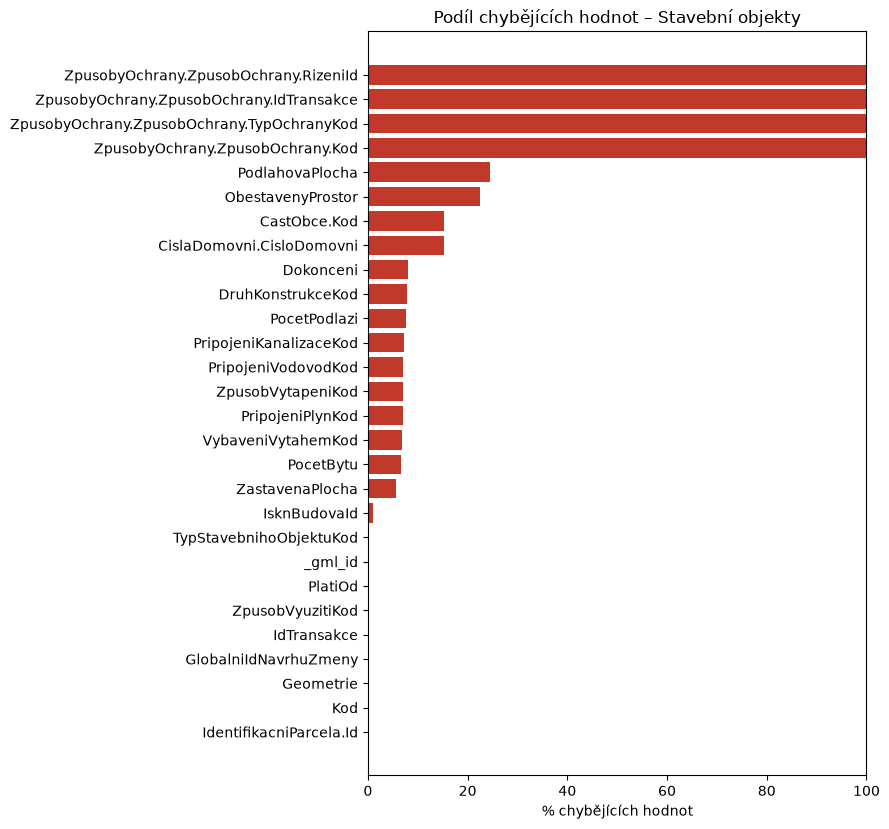

In [85]:
# Vizualizace chybějících hodnot pro stavební objekty
fig, ax = plt.subplots(figsize=(9, max(4, len(missing_so) * 0.3)))
plot_data = missing_so.sort_values("chybi_procent")
ax.barh(plot_data.index, plot_data["chybi_procent"], color="#c0392b")
ax.set_xlabel("% chybějících hodnot")
ax.set_title("Podíl chybějících hodnot – Stavební objekty")
ax.set_xlim(0, 100)
plt.tight_layout()
plt.show()


In [86]:
# Stejná analýza pro ostatní entity
for name, df in dfs.items():
    if name == "StavebniObjekty":
        continue
    print(missing_report(df, name))
    print()


--- Obce (celkem 1 záznamů) ---
                               chybi_pocet  chybi_procent  vyplneno_pocet
Kod                                      0            0.0               1
Nazev                                    0            0.0               1
StatusKod                                0            0.0               1
Okres.Kod                                0            0.0               1
Pou.Kod                                  0            0.0               1
PlatiOd                                  0            0.0               1
IdTransakce                              0            0.0               1
GlobalniIdNavrhuZmeny                    0            0.0               1
MluvnickeCharakteristiky.Pad2            0            0.0               1
MluvnickeCharakteristiky.Pad3            0            0.0               1
MluvnickeCharakteristiky.Pad4            0            0.0               1
MluvnickeCharakteristiky.Pad6            0            0.0               1
Mluvni

## 4. Popisné statistiky číselných atributů

Např. zastavěná plocha, obestavěný prostor, podlahová plocha, počet bytů,
počet podlaží a rok dokončení.

In [87]:
# Identifikace číselných a kategoriálních sloupců
numeric_cols = df_so.select_dtypes(include=['number']).columns.tolist()

print("Číselné sloupce:", numeric_cols)



Číselné sloupce: ['PocetBytu', 'PocetPodlazi', 'ZastavenaPlocha', 'ObestavenyProstor', 'PodlahovaPlocha']


In [88]:
# Popisné statistiky pro číselné sloupce
desc = df_so[numeric_cols].describe()
desc.loc["chybi_procent"] = round(df_so[numeric_cols].isna().mean() * 100, 1)

if "Dokonceni" in df_so.columns:
    dok_year = pd.to_datetime(df_so["Dokonceni"], errors="coerce").dt.year
    desc["Dokonceni_rok"] = dok_year.describe().round(1)
    desc.loc["chybi_procent", "Dokonceni_rok"] = round(dok_year.isna().mean() * 100, 1)

desc = desc.round(2)
desc


,PocetBytu,PocetPodlazi,ZastavenaPlocha,ObestavenyProstor,PodlahovaPlocha,Dokonceni_rok
count,1255.00,1240.00,1267.00,1041.00,1014.00,1236.0
mean,1.66,1.91,153.55,1001.08,241.06,2008.1
std,4.72,0.69,359.13,2865.53,760.95,21.2
min,0.00,1.00,3.00,4.00,2.00,1900.0
25%,1.00,2.00,72.00,451.00,123.00,2007.0
50%,1.00,2.00,111.00,598.00,150.00,2014.0
75%,1.00,2.00,159.00,845.00,198.00,2020.0
max,110.00,5.00,9163.00,61669.00,20618.00,2026.0
chybi_procent,6.60,7.70,5.70,22.50,24.50,8.0


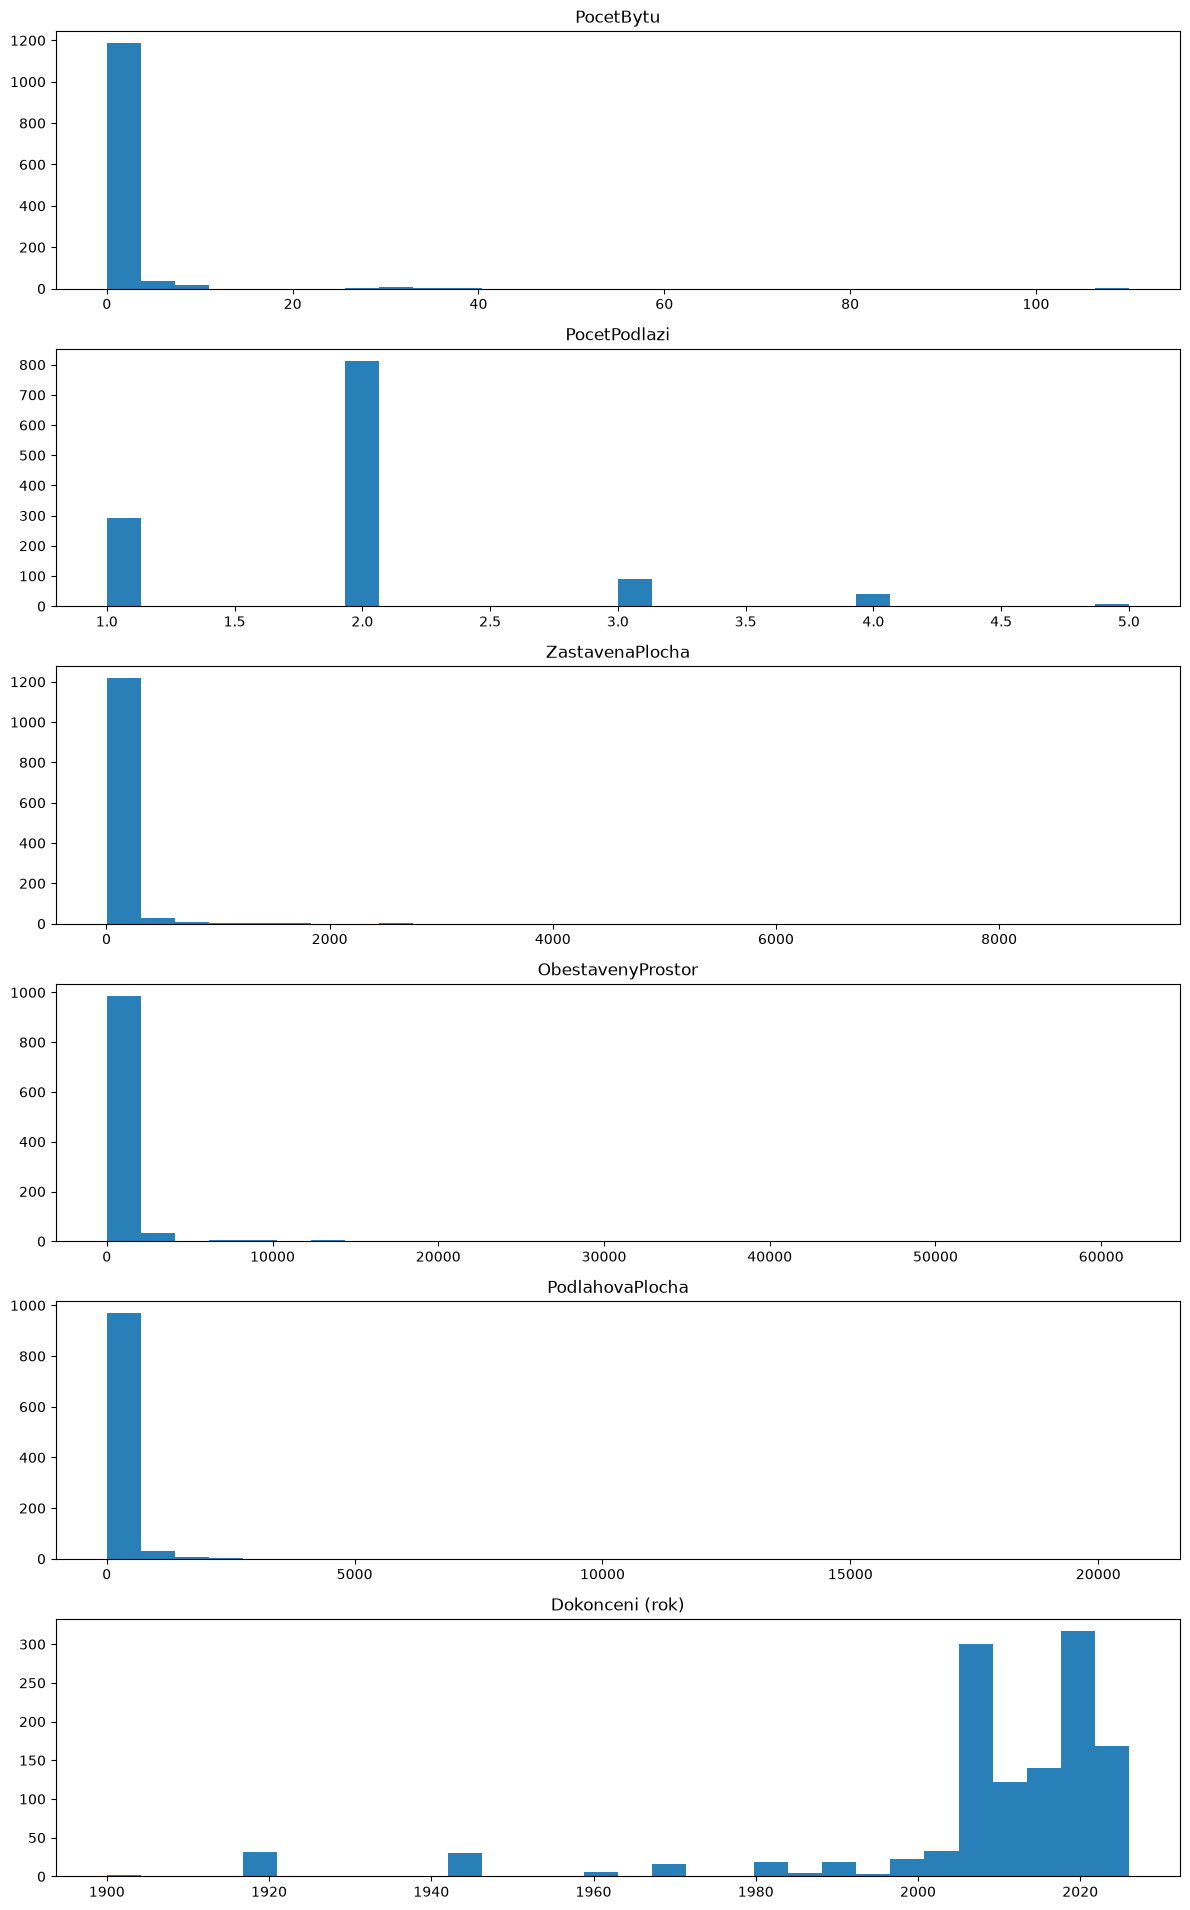

In [89]:
# Histogramy pro hlavní kvantitativní atributy budov

n = len(numeric_cols) + (1 if "Dokonceni" in df_so.columns else 0)
fig, axes = plt.subplots(n, 1, figsize=(12, 3.2 * n))
if n == 1:
    axes = [axes]

for ax, col in zip(axes, numeric_cols):
    data = df_so[col].dropna()
    ax.hist(data, bins=30, color="#2980b9")
    ax.set_title(col.split(".")[-1])
if "Dokonceni" in df_so.columns:
    ax = axes[-1]
    data = df_so["Dokonceni"].dropna().dt.year
    ax.hist(data, bins=30, color="#2980b9")
    ax.set_title("Dokonceni (rok)")

plt.tight_layout()
plt.show()


## 5. Frekvenční analýza kódovaných (kategoriálních) atributů

RÚIAN používá číselníkové kódy (např. způsob vytápění, typ konstrukce,
napojení na sítě). Význam kódů zjistíme z příslušných číselníků ČÚZK.

In [90]:
categorical_cols = ["TypStavebnihoObjektuKod", "ZpusobVyuzitiKod", "DruhKonstrukceKod"]

# --- načtení číselníků a přidání popisů kódovaných atributů ---
lookup_sources = {
    "TypStavebnihoObjektuKod": "CS_TYP_STAVEBNIHO_OBJEKTU.csv",
    "ZpusobVyuzitiKod": "CE_ZPUSOB_VYUZITI_OBJEKTU.csv",
    "DruhKonstrukceKod": "CE_DRUH_KONSTRUKCE.csv",
}


def repair_cp1250_text(value):
    if not isinstance(value, str):
        return value
    try:
        return value.encode("latin1").decode("cp1250")
    except Exception:
        return value

for col, csv_path in lookup_sources.items():
    if col not in df_so.columns:
        print(f"Sloupec {col} není v df_so; přeskočeno.")
        continue

    try:
        lookup_df = pd.read_csv(csv_path, sep=";", encoding="utf-8-sig")
    except UnicodeDecodeError:
        lookup_df = pd.read_csv(csv_path, sep=";", encoding="latin1")

    if "KOD" not in lookup_df.columns:
        print(f"Soubor {csv_path} neobsahuje sloupec KOD.")
        continue

    lookup_df["KOD"] = lookup_df["KOD"].astype(str).str.strip()
    lookup_df["NAZEV"] = lookup_df["NAZEV"].astype(str).str.strip().apply(repair_cp1250_text)
    lookup_df = lookup_df.drop_duplicates(subset=["KOD"], keep="first")

    desc_col = f"{col}_desc"
    df_so[col] = df_so[col].astype("string").str.strip()
    lookup_map = dict(zip(lookup_df["KOD"], lookup_df["NAZEV"]))
    df_so[desc_col] = df_so[col].map(lookup_map)


# Frekvenční analýza kódovaných atributů s popisy
for col in categorical_cols:
    if col not in df_so.columns:
        continue
    desc_col = f"{col}_desc"
    vc = (
        df_so.groupby([col, desc_col])
        .size()
        .reset_index(name="pocet")
        .sort_values("pocet", ascending=False)
        .head(20)
    )
    print(f"\n--- {col} s popisem ---")
    display(vc)



--- TypStavebnihoObjektuKod s popisem ---


,TypStavebnihoObjektuKod,TypStavebnihoObjektuKod_desc,pocet
0,1,budova s číslem popisným,1132
2,3,budova bez č.p. /č.ev.,204
1,2,budova s číslem evidenčním,7



--- ZpusobVyuzitiKod s popisem ---


,ZpusobVyuzitiKod,ZpusobVyuzitiKod_desc,pocet
13,7,rodinný dům,1035
8,18,garáž,77
9,19,jiná stavba,73
12,6,bytový dům,69
7,16,stavba technického vybavení,28
6,15,stavba občanského vybavení,13
4,13,zemědělská stavba,13
3,12,stavba pro výrobu a skladování,7
11,5,objekt občanské vybavenosti,7
14,8,stavba pro rodinnou rekreaci,5



--- DruhKonstrukceKod s popisem ---


,DruhKonstrukceKod,DruhKonstrukceKod_desc,pocet
0,1,"Cihly, tvárnice, cihlové bloky",699
1,10,"Kámen, cihly, tvárnice vč. kombinací",313
13,7,Jiné materiály a kombinace,62
9,6,Dřevo,58
5,4,Stěnové panely,43
14,9,Nezjištěno,40
6,41,Stěnové panely - beton a železobeton,5
2,11,Monolit,4
11,62,Dřevo - Lehký rámový skelet (panelová montáž),4
3,2,Kámen,3


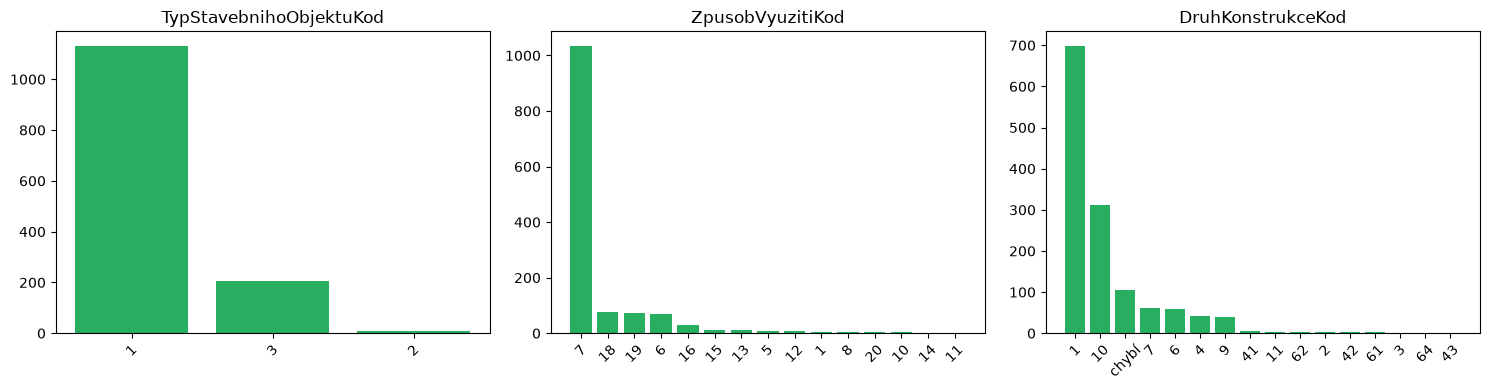

In [91]:
# Grafické znázornění 
key_cat = [c for c in categorical_cols if c in df_so.columns]
fig, axes = plt.subplots(1, len(key_cat), figsize=(5 * len(key_cat), 4))
if len(key_cat) == 1:
    axes = [axes]
for ax, col in zip(axes, key_cat):
    vc = df_so[col].value_counts(dropna=False)
    labels = [("chybí" if pd.isna(v) else str(v)) for v in vc.index]
    ax.bar(labels, vc.values, color="#27ae60")
    ax.set_title(col.split(".")[-1])
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()


## 6. Analýza časové platnosti (`PlatiOd` vs  `Dokonceni`)



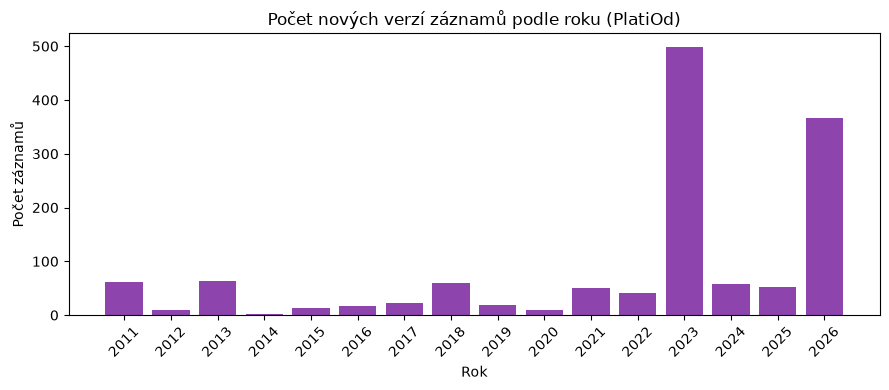

In [92]:
# Časové rozložení začátků platnosti (kdy vznikaly / se měnily záznamy)
platiOd_col = [c for c in df_so.columns if c.endswith("PlatiOd")][0]
platnost_od_rok = df_so[platiOd_col].dt.year.value_counts().sort_index()
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(platnost_od_rok.index.astype(str), platnost_od_rok.values, color="#8e44ad")
ax.set_title("Počet nových verzí záznamů podle roku (PlatiOd)")
ax.set_xlabel("Rok")
ax.set_ylabel("Počet záznamů")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


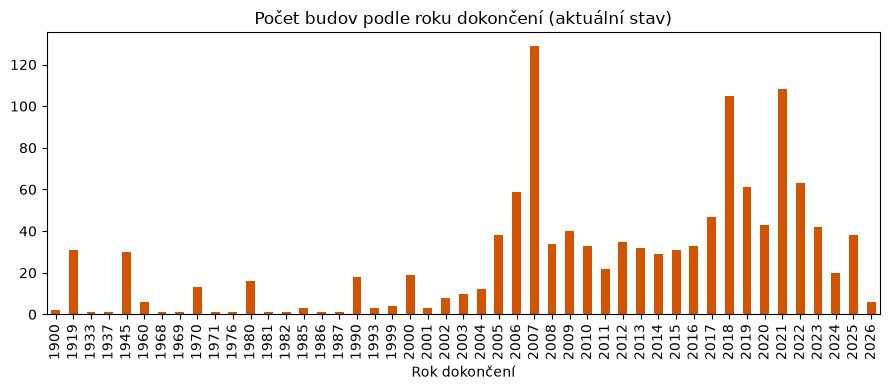

In [93]:

# Rok dokončení aktuálně platných budov (vývoj zástavby v čase)
if "Dokonceni" in df_so.columns:
    dokonceni_rok = df_so["Dokonceni"].dropna().dt.year
    fig, ax = plt.subplots(figsize=(9, 4))
    dokonceni_rok.value_counts().sort_index().plot(kind="bar", ax=ax, color="#d35400")
    ax.set_title("Počet budov podle roku dokončení (aktuální stav)")
    ax.set_xlabel("Rok dokončení")
    plt.tight_layout()
    plt.show()


## 7. Kontrola konzistence a kvality dat

- Kontrola duplicitních `_gml_id` (mělo by být unikátní)
- Kontrola špatně zadaných stavebně technických atributů

In [94]:
# Unikátnost ID
duplicidy = df_so['_gml_id'].duplicated().sum()
print(f"\nDuplicitní gml:id: {duplicidy}")

# Datum dokonceni
if "Dokonceni" in df_so.columns:
    dokonceni_dt = pd.to_datetime(df_so["Dokonceni"], errors='coerce')
    v_budoucnu = df_so[dokonceni_dt > pd.Timestamp.now()]
    print(f"Budovy s datem dokončení v budoucnosti: {len(v_budoucnu)}")


# Validace stavebně-technických atributů 
if "PocetPodlazi" in df_so.columns:
    podlazi_numeric = pd.to_numeric(df_so["PocetPodlazi"], errors='coerce')
    neplatna_podlazi = df_so[podlazi_numeric <= 0]
    print(f"Objekty s počtem podlaží <= 0: {len(neplatna_podlazi)}")
    neplatna_podlazi = df_so[podlazi_numeric > 50]
    print(f"Objekty s počtem podlaží > 50: {len(neplatna_podlazi)}")

if "ZastavenaPlocha" in df_so.columns:
    plocha_numeric = pd.to_numeric(df_so["ZastavenaPlocha"], errors='coerce')
    neplatna_plocha = df_so[plocha_numeric <= 0]
    print(f"Objekty se zastavěnou plochou <= 0 m²: {len(neplatna_plocha)}")



Duplicitní gml:id: 0
Budovy s datem dokončení v budoucnosti: 0
Objekty s počtem podlaží <= 0: 0
Objekty s počtem podlaží > 50: 0
Objekty se zastavěnou plochou <= 0 m²: 0


## 8. Souhrnná profilovací tabulka (export do CSV)

Vytvoří jednu přehlednou tabulku entitu StavebniObjekty: název sloupce, datový typ,
počet/procento chybějících hodnot, počet unikátních hodnot a ukázkovou hodnotu.
Tabulky se uloží do `profiling_aktualni_SO.csv`.

In [95]:
def build_profile_table(df):
    rows = []
    for col in df.columns:
        non_null = df[col].dropna()
        sample = non_null.iloc[0] if len(non_null) else None
        rows.append({
            "sloupec": col,
            "dtype": str(df[col].dtype),
            "pocet_hodnot": len(df) - df[col].isna().sum(),
            "chybi_pocet": df[col].isna().sum(),
            "chybi_procent": round(df[col].isna().mean() * 100, 1),
            "pocet_unikatnich": df[col].nunique(dropna=True),
            "ukazka_hodnoty": sample,
        })
    return pd.DataFrame(rows).sort_values("chybi_procent", ascending=False)


prof = build_profile_table(df_so)
profile_table = prof
out_path = f"profiling_aktualni_SO.csv"
# prof.to_csv(out_path, index=False, encoding="utf-8-sig")
# print(f"Uloženo: {out_path}  ({len(prof)} sloupců)")

profile_table


TypeError: unhashable type: 'list'